In [1]:
import seaborn as sns

In [22]:
penguins_df = sns.load_dataset("penguins")

In [7]:
print(penguins_df.head(1))

  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   

   body_mass_g   sex  
0       3750.0  Male  


In [4]:
print(penguins_df.describe())

       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count      342.000000     342.000000         342.000000   342.000000
mean        43.921930      17.151170         200.915205  4201.754386
std          5.459584       1.974793          14.061714   801.954536
min         32.100000      13.100000         172.000000  2700.000000
25%         39.225000      15.600000         190.000000  3550.000000
50%         44.450000      17.300000         197.000000  4050.000000
75%         48.500000      18.700000         213.000000  4750.000000
max         59.600000      21.500000         231.000000  6300.000000


In [5]:
print(penguins_df.columns)

Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='str')


# **Part - 1**

**1 - Using the body_mass_g column from the Palmer Penguins dataset, demonstrate the**
**effect of an outlier by adding an extreme value, compare the mean and median before**
**and after the outlier, and write your observations based on the `results in your own**
**words as comments.**

In [10]:
# mean and median of body_mass_g before adding an outlier value
mean_before = penguins_df['body_mass_g'].mean()
median_before = penguins_df['body_mass_g'].median()

# Adding an outlier value to the body_mass_g column
penguins_df.loc[len(penguins_df)] = ['Adelie', 'Torgersen', 39.1, 18.7, 181.0, 1000000, 'Female']

# mean and median of body_mass_g after adding an outlier value
mean_after = penguins_df['body_mass_g'].mean()
median_after = penguins_df['body_mass_g'].median()

print(f"Mean before adding outlier: {mean_before}")
print(f"Median before adding outlier: {median_before}")
print(f"Mean after adding outlier: {mean_after}")
print(f"Median after adding outlier: {median_after}")

Mean before adding outlier: 4758.720930232558
Median before adding outlier: 4050.0
Mean after adding outlier: 7643.478260869565
Median after adding outlier: 4050.0


Thus, we can observe that mean of the column has changed drastically but median of the column remains the same. This happens because mean is the center of mass of all the values in the dataset and in that outlier value which is large can affect but median is the central value of the dataset and it is not affected by any outlier values.

In [ ]:
# remove outlier value from the body_mass_g column
penguins_df = sns.load_dataset("penguins")

**2 - Using the flipper_length_mm column from the Palmer Penguins dataset, create**
**histograms to compare the distribution of flipper lengths across different penguin**
**species, and write your observations based on the visualization and results in your own**
**words as comments.**

In [23]:
# count the frequency of each species in the dataset
species_counts = penguins_df['species'].value_counts()
print(species_counts)

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64


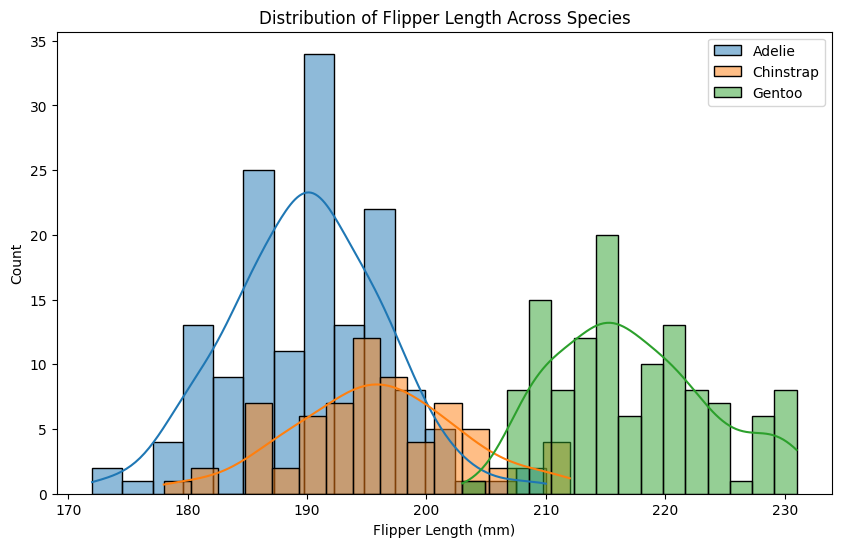

In [24]:
# histograms to compare the distribution of flipper length across species
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for species in penguins_df['species'].unique(): # this finds species like this ['Adelie', 'Chinstrap', 'Gentoo']
    # penguins_df['species'] == species - if the row has species as we have selected above then that row becomes True
    # penguins_df[penguins_df['species'] == species] - penguins_df[True] - this will get all the rows which are true
    # ['flipper_length_mm'] - this will get the flipper length column of the rows which are true
    # data is like this [181.0, 186.0, 195.0, 193.0]
    data = penguins_df[penguins_df['species'] == species]['flipper_length_mm'].dropna()
    sns.histplot(data, bins=15, kde=True, label=species, alpha=0.5)
    # alpha=0.5 - make the histogram semi-transparent so overlapping histograms are easier to see.
    # bins=15 - divide the x-axis into 15 intervals.

plt.xlabel("Flipper Length (mm)")
plt.ylabel("Count")
plt.title("Distribution of Flipper Length Across Species")
plt.legend()
plt.show()

There are 3 species and the hist plot shows that how many penguins of that particular species have how much flipper length. 

What is KDE curve? it shows that same thing that bars in the histogram show. just the only better thing is that it is a smooth curve so it is easier to see where more data is. like we can see in the graph above for Adelie. the curve peaks at 190 mm which means that maximum penguins of that species have flipper length of approximately 190 mm. Similarly for Chinstrap is about 195 mm and for Gentoo it is around 215 mm.

Lower part of curve means that less number of penguins have that flipper length.

**3 - Using the body_mass_g column from the Palmer Penguins dataset, compare the**
**distribution of body mass across different penguin species by calculating the variance,**
**skewness, kurtosis, and Pearson's coefficients of skewness, and write your observations**
**based on the results in your own words as comments.**

In [25]:
# compare distribution of body mass across species using variance, skewness, kurtosis, pearson's coefficient of skewness
for species in penguins_df['species'].unique():
    data = penguins_df[penguins_df['species'] == species]['body_mass_g'].dropna()
    variance = data.var()
    skewness = data.skew()
    kurtosis = data.kurtosis()
    pearson_skewness = 3 * (data.mean() - data.median()) / data.std()

    print(f"Species: {species}")
    print(f"Variance: {variance}")
    print(f"Skewness: {skewness}")
    print(f"Kurtosis: {kurtosis}")
    print(f"Pearson's Coefficient of Skewness: {pearson_skewness}")
    print("\n")

Species: Adelie
Variance: 210282.8918322296
Skewness: 0.28533613464986846
Kurtosis: -0.5737375680498196
Pearson's Coefficient of Skewness: 0.004332537565751998


Species: Chinstrap
Variance: 147713.45478489902
Skewness: 0.2474331287920131
Kurtosis: 0.5933788890102161
Pearson's Coefficient of Skewness: 0.2582764641834771


Species: Gentoo
Variance: 254133.1800613088
Skewness: 0.0696348544218767
Kurtosis: -0.7227912303548982
Pearson's Coefficient of Skewness: 0.45237340895831424




- variance means that how spread is the data, higher the variance means that body mass vary a lot and less means body mass are more similar. Adelie was showing a very high variance because we added outlier above and now we need to remove outlier from the data to get proper values. From the variance values we can say that Gentoo has highest spread, Adelie has moderate spread and Chinstrap has lowest spread and it is evident in histogram.

- skewness means it shows whether data is symmetric or not. 0 means that data is symmetric and mean and median are same. left skewed means mean is on left of median value and more data is on left side of median and vice versa for right skewed. right skewed will have positive value and left will have negative. Adelie and Chinstrap are a little right skewed while Gentoo is almost symmetric.

- kurtosis means that how much outliers are present in the dataset. 0 means that there are no outlier and clusters are around mean. positive means that there are more outlier and the possibility of getting higher value is more. negative means that there are less outlier means that there will be no mean, it will be flat from peak. among all none is near normal distribution. Adelie and gentoo have negative kurtosis. chinstrap is a little near normal.

- pearson's coefficient is another way of seeing skewness. Adelie is amlost symmetric. other 2 are right skewed

**4 - Using the body_mass_g column from the Palmer Penguins dataset, calculate the five-**
**number summary (minimum, Q1, median, Q3, and maximum), determine the interquartile range(IQR)create grouped boxplots for each penguin species, and write your observations based on the** **visualization and results in your own words as comments.**

Five Number Summary
-------------------
Minimum : 2700.0
Q1      : 3550.0
Median  : 4050.0
Q3      : 4750.0
Maximum : 6300.0

Interquartile Range (IQR): 1200.0


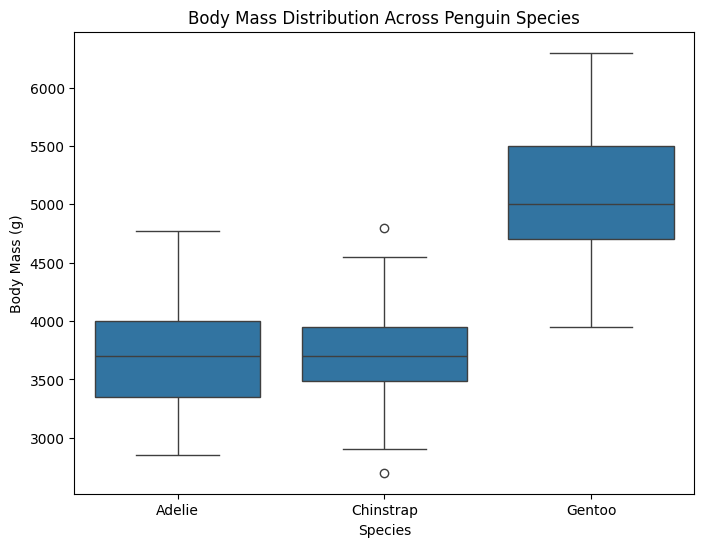

In [26]:
# Using the body_mass_g column from the Palmer Penguins dataset, calculate the five-number summary (minimum, Q1, median, Q3, and maximum), determine the interquartile range (IQR), create grouped boxplots for each penguin species, and write your observations based on the visualization and results in your own words as comments.
body_mass = penguins_df["body_mass_g"].dropna()
minimum = body_mass.min()
q1 = body_mass.quantile(0.25)
median = body_mass.median()
q3 = body_mass.quantile(0.75)
maximum = body_mass.max()
print("Five Number Summary")
print("-------------------")
print("Minimum :", minimum)
print("Q1      :", q1)
print("Median  :", median)
print("Q3      :", q3)
print("Maximum :", maximum)

iqr = q3 - q1
print("\nInterquartile Range (IQR):", iqr)

plt.figure(figsize=(8,6))
sns.boxplot(
    data=penguins_df,
    x="species",
    y="body_mass_g"
)
plt.xlabel("Species")
plt.ylabel("Body Mass (g)")
plt.title("Body Mass Distribution Across Penguin Species")
plt.show()


- The lightest penguin weighs 2700 g.
- 25% of penguins weigh 3550 g or less.
- Half of the penguins weigh less than 4050 g and half weigh more.
- 75% of penguins weigh 4750 g or less.
- The heaviest penguin weighs 6300 g.
- middle 50% of penguin body masses lie within a range of 1200 g.

From box plot:
- Adelie has median around 3700 g, there are no outlier and it is moderately spread
- chinstrap has median aroung 3700 g, there are 2 outlier and spread is moderate.
- gentoo has the highest median of 5000g, no outliers visible and the spread is larger than others.

**5 - Using the flipper_length_mm and body_mass_g columns from the Palmer Penguins**
**dataset, create a scatter plot, fit a linear regression line, calculate the covariance and**
**Pearson correlation coefficient, and write your observations based on the visualization**
**and results in your own words as comments.**

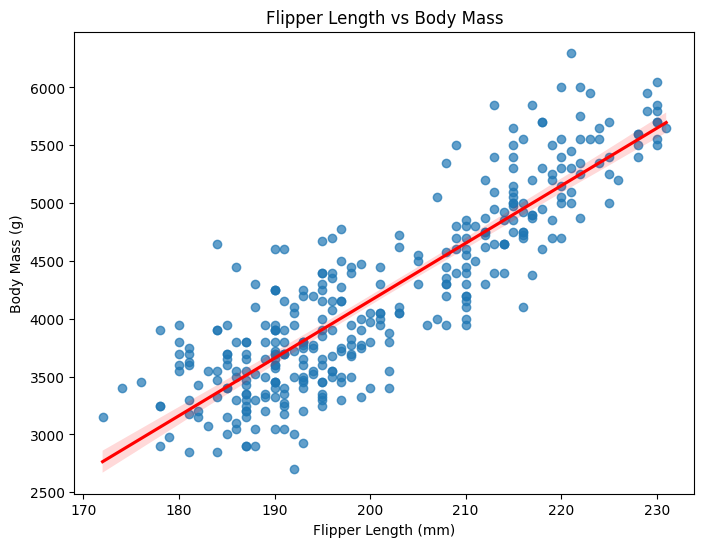

In [27]:
data = penguins_df[['flipper_length_mm', 'body_mass_g']].dropna()
plt.figure(figsize=(8,6))
sns.regplot(
    data=data,
    x='flipper_length_mm',
    y='body_mass_g',
    scatter_kws={'alpha':0.7},
    line_kws={'color':'red'}
)
plt.title("Flipper Length vs Body Mass")
plt.xlabel("Flipper Length (mm)")
plt.ylabel("Body Mass (g)")
plt.show()

- regression line is just there to summarize the points into a single line
- the line means that as the flipper length increases the body mass increases

In [28]:
covariance = data['flipper_length_mm'].cov(data['body_mass_g'])

print("Covariance:", covariance)

Covariance: 9824.416062149512


- positive covariance means that as one value increase other also increases and it is evident in the graph

In [29]:
correlation = data['flipper_length_mm'].corr(data['body_mass_g'])

print("Pearson Correlation Coefficient:", correlation)

Pearson Correlation Coefficient: 0.8712017673060117


- this also indicates the same that both have positive linear relationship

**6 - Using the body_mass_g column from the Palmer Penguins dataset, group the data based**
**on the island column and calculate the total penguin biomass supported by each island.**
**Create a pie chart to show the proportion of total biomass contributed by each island**
**and a bar chart to compare the absolute total biomass values. Write your observations**
**based on the visualization and results in your own words as comments.**

In [30]:
data = penguins_df[['island', 'body_mass_g']].dropna()
biomass = data.groupby('island')['body_mass_g'].sum()
print(biomass)

island
Biscoe       787575.0
Dream        460400.0
Torgersen    189025.0
Name: body_mass_g, dtype: float64


this simply shows that total body mass in each island

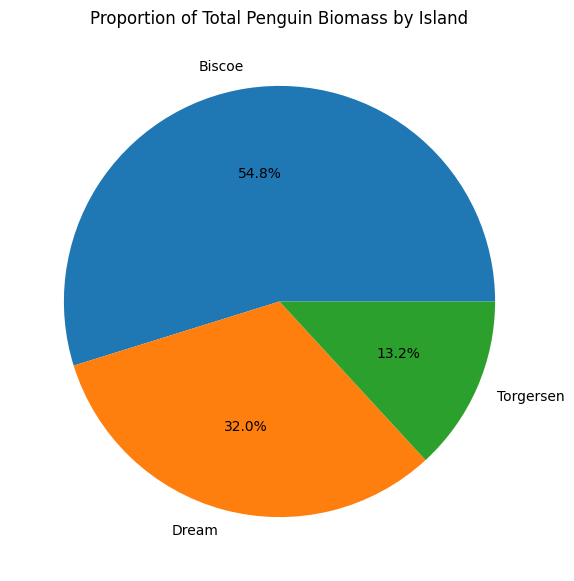

In [33]:
plt.figure(figsize=(7,7))
plt.pie(biomass,labels=biomass.index, autopct='%1.1f%%')
plt.title("Proportion of Total Penguin Biomass by Island")
plt.show()

- there is more mass on Biscoe island, then in Dream and then in Torgersen

**7 - Using the bill_length_mm and bill_depth_mm columns from the Palmer Penguins**
**dataset, investigate whether the relationship between bill length and bill depth varies**
**across different penguin species. Create a scatter plot with different colors representing**
**each species to identify species-specific patterns and relationships. Write your**
**observations based on the visualization and results in your own words as comments.**

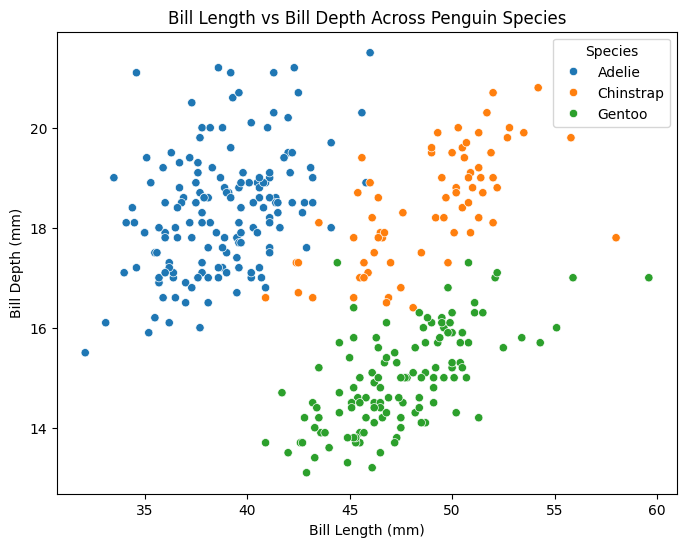

In [36]:
data = penguins_df[['bill_length_mm', 'bill_depth_mm', 'species']].dropna()
plt.figure(figsize=(8,6))
sns.scatterplot(data=data,x='bill_length_mm',y='bill_depth_mm',hue='species')
plt.title("Bill Length vs Bill Depth Across Penguin Species")
plt.xlabel("Bill Length (mm)")
plt.ylabel("Bill Depth (mm)")
plt.legend(title="Species")
plt.show()

- Adelie has moderate short and deep bills
- Chinstrap has long and deep bills
- gentoo has long and shallow bills

# **PART – 2 Analysis on Dow Jones Time-Series Dataset**

In [37]:
import seaborn as sns
dowjones_df = sns.load_dataset("dowjones")

**1 - Using the Price column from the Dow Jones dataset, calculate the five-number**
**summary (minimum, Q1, median, Q3, and maximum) and determine the interquartile**
**range (IQR). Group the data using the engineered Decade column and create boxplots**
**to compare the distribution, spread, and median price values across different decades.**
**Write your observations based on the visualization and results in your own words as**
**comments.**

Five Number Summary
-------------------
Minimum : 46.85
Q1      : 106.9
Median  : 172.27
Q3      : 436.73
Maximum : 985.93
IQR : 329.83000000000004


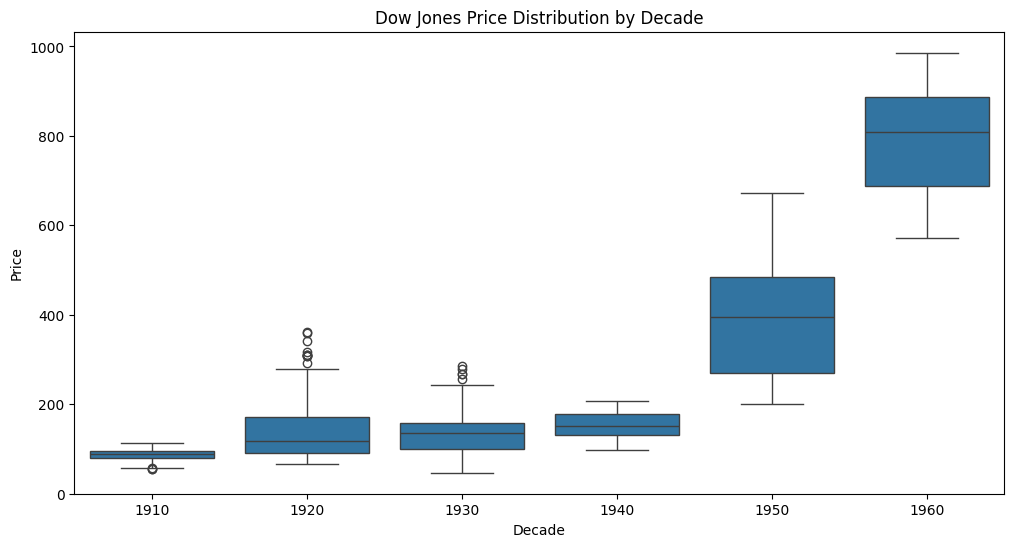

In [38]:
import matplotlib.pyplot as plt
import pandas as pd
dowjones_df['Date'] = pd.to_datetime(dowjones_df['Date'])
dowjones_df['Decade'] = (dowjones_df['Date'].dt.year // 10) * 10
price = dowjones_df['Price'].dropna()
minimum = price.min()
q1 = price.quantile(0.25)
median = price.median()
q3 = price.quantile(0.75)
maximum = price.max()
print("Five Number Summary")
print("-------------------")
print("Minimum :", minimum)
print("Q1      :", q1)
print("Median  :", median)
print("Q3      :", q3)
print("Maximum :", maximum)

iqr = q3 - q1
print("IQR :", iqr)

plt.figure(figsize=(12,6))
sns.boxplot(data=dowjones_df,x='Decade',y='Price')
plt.title("Dow Jones Price Distribution by Decade")
plt.xlabel("Decade")
plt.ylabel("Price")
plt.show()

- 46.85 is the lowest Dow Jones price in the dataset.
- 25% of the prices are less than or equal to 106.90.
- Half of the prices are below 172.27 and half are above it.
- 75% of the prices are less than or equal to 436.73.
- 985.93 is the Highest Dow Jones price in the dataset.
- middle 50% of Dow Jones prices lie within a range of 329.83

From Box plot:
- Both the median and the overall price levels generally increase over time.
- Price variability increased over time. The stock market experienced larger fluctuations in later decades.
- 1910,1920 and 1930 have outliers

**2 - Using the Date and Price columns from the Dow Jones dataset, create a time-series line**
**plot to visualize the change in index prices over time. Convert dates into numerical**
**values and fit a linear regression model to identify the overall trend in the data. Display**
**the regression trendline along with the original time-series data, calculate the Pearson**
**correlation coefficient and R-squared value, and write your observations based on the**
**visualization and results in your own words as comments.**

In [39]:
dowjones_df = sns.load_dataset("dowjones")
dowjones_df['Date'] = pd.to_datetime(dowjones_df['Date'])
data = dowjones_df[['Date', 'Price']].dropna()
data['Date_Num'] = data['Date'].map(pd.Timestamp.toordinal)

# linear regression model
import numpy as np
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X = data[['Date_Num']]
y = data['Price']
model = LinearRegression()
model.fit(X, y)
predicted = model.predict(X)

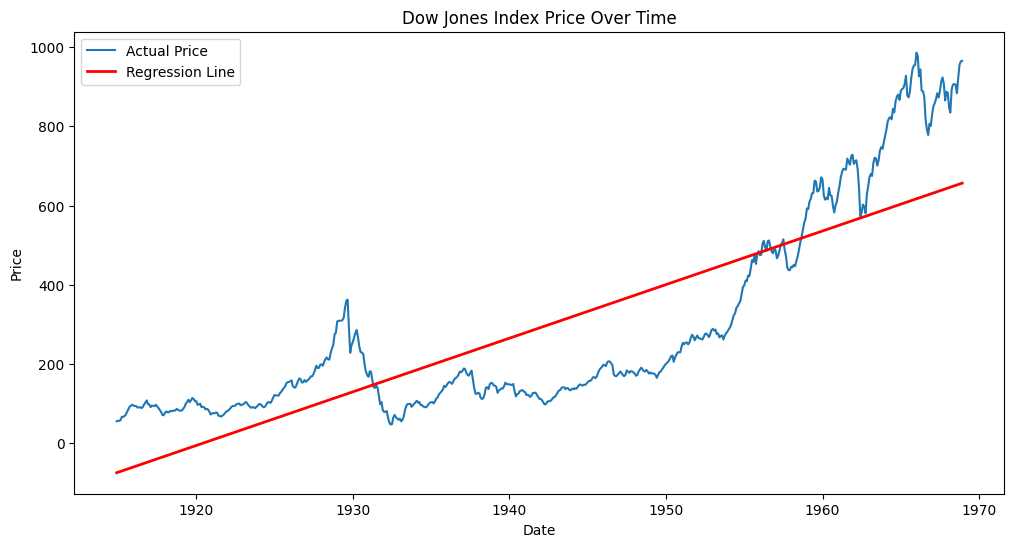

In [40]:
plt.figure(figsize=(12,6))
plt.plot(data['Date'],data['Price'],label='Actual Price')
plt.plot(data['Date'],predicted,color='red',linewidth=2,label='Regression Line')
plt.title("Dow Jones Index Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

- blue curve is the actual price vs date curve which is made from actual values
- red line is regression line
- in blue line there are ups and downs
- but regression line shows that overall there is increasing trend
- As time increases, the Dow Jones index price generally increases.

In [41]:
correlation, _ = pearsonr(data['Date_Num'],data['Price'])
print("Pearson Correlation:", correlation)

Pearson Correlation: 0.8263536194947425


- it is positive value which means that trend is increasing
- Later years generally have higher index prices than earlier years

In [42]:
r2 = r2_score(y,predicted)
print("R-squared:", r2)

R-squared: 0.6828603044520613


- what does r2 score show? How well the regression line explains the variation in the data
- r2 score = 1 means it perfectly fits
- r2 score = 0 means it does not explain anything
- An R2 score of 0.68 indicates that the regression model provides a reasonably good fit, although it does not explain every fluctuation in the data